<a href="https://colab.research.google.com/github/fariya09ahmed-commits/Fariya-Ahmed/blob/main/final_p_1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, warnings, platform
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from scipy.stats import chi2

# ── sklearn ──────────────────────────────────────────────────────────────────
from sklearn.model_selection  import (train_test_split, StratifiedKFold,
                                       cross_val_score, cross_validate,
                                       GridSearchCV)
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.pipeline         import Pipeline
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import (RandomForestClassifier,
                                       GradientBoostingClassifier)
from sklearn.linear_model     import LogisticRegression
from sklearn.svm              import SVC
from sklearn.neural_network   import MLPClassifier
from sklearn.inspection       import permutation_importance
from sklearn.calibration      import CalibratedClassifierCV, calibration_curve
from sklearn.metrics          import (accuracy_score, precision_score,
                                       recall_score, f1_score,
                                       matthews_corrcoef, cohen_kappa_score,
                                       roc_auc_score, average_precision_score,
                                       confusion_matrix, classification_report,
                                       roc_curve, precision_recall_curve, auc,
                                       brier_score_loss)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── imbalanced-learn ──────────────────────────────────────────────────────────
from imblearn.combine  import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

# ── Optional heavy libraries ──────────────────────────────────────────────────
try:
    from xgboost  import XGBClassifier;  _HAS_XGB  = True
except ImportError: _HAS_XGB = False

try:
    from lightgbm import LGBMClassifier; _HAS_LGB  = True
except ImportError: _HAS_LGB = False

try:
    from catboost import CatBoostClassifier; _HAS_CAT = True
except ImportError: _HAS_CAT = False

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    _HAS_OPTUNA = True
except ImportError: _HAS_OPTUNA = False

try:
    import shap;  _HAS_SHAP = True
except ImportError: _HAS_SHAP = False

try:
    from lime import lime_tabular; _HAS_LIME = True
except ImportError: _HAS_LIME = False

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Publication-quality plotting ──────────────────────────────────────────────
sns.set_theme(style='whitegrid', context='paper')
mpl.rcParams.update({
    'figure.dpi'        : 120,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'font.family'       : 'serif',
    'font.size'         : 11,
    'axes.titlesize'    : 12,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'legend.fontsize'   : 10,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

FIG_DIR = 'figures'; os.makedirs(FIG_DIR, exist_ok=True)
TAB_DIR = 'tables';  os.makedirs(TAB_DIR, exist_ok=True)

def savefig(name, fig=None):
    fig = fig or plt.gcf()
    for ext in ('png', 'pdf'):
        fig.savefig(os.path.join(FIG_DIR, f'{name}.{ext}'),
                    dpi=300, bbox_inches='tight')
    print(f'  → saved {name}.png / .pdf')

print('All libraries imported. Optional packages:')
for lib, flag in [('XGBoost',_HAS_XGB),('LightGBM',_HAS_LGB),
                  ('CatBoost',_HAS_CAT),('Optuna',_HAS_OPTUNA),
                  ('SHAP',_HAS_SHAP),('LIME',_HAS_LIME)]:
    print(f'  {lib:12s}: {"✓" if flag else "✗  (pip install)"}')

All libraries imported. Optional packages:
  XGBoost     : ✓
  LightGBM    : ✓
  CatBoost    : ✗  (pip install)
  Optuna      : ✗  (pip install)
  SHAP        : ✓
  LIME        : ✗  (pip install)


In [3]:

from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [4]:
# ── Colab mount (comment out if running locally) ─────────────────────────────
# from google.colab import drive; drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/paper1 data dengue detenction hematological data set.csv'
df = pd.read_csv(DATA_PATH)

print(f'Records  : {df.shape[0]}')
print(f'Features : {df.shape[1] - 1}  (+1 target)')
df.head()

Records  : 1523
Features : 18  (+1 target)


,Gender,Age,Hemoglobin(g/dl),Neutrophils(%),Lymphocytes(%),Monocytes(%),Eosinophils(%),RBC,HCT(%),MCV(fl),MCH(pg),MCHC(g/dl),RDW-CV(%),Total Platelet Count(/cumm),MPV(fl),PDW(%),PCT(%),Total WBC count(/cumm),Result
0,Male,21,14.8,48,47,3,2,5,48.00,96.0,29.60,30.8,11.6,112000,10.70,15.40,0.120,5100,positive
1,Male,30,15.0,47,49,6,3,5,49.80,96.1,28.40,29.5,11.8,96000,10.60,15.80,0.121,4500,positive
2,Male,51,16.3,41,48,4,5,5,50.10,93.5,31.30,32.7,13.5,184000,10.40,16.40,0.130,6000,negative
3,Female,26,12.3,46,49,7,5,5,44.00,90.0,30.50,30.5,14.7,167000,8.10,17.10,0.110,5000,negative
4,Male,35,16.1,45,46,4,4,5,50.53,91.0,29.12,29.2,15.2,155000,10.52,12.34,0.150,4600,negative


In [5]:
desc = df.describe().T[['count','mean','std','min','25%','50%','75%','max']]
desc.columns = ['N','Mean','SD','Min','Q1','Median','Q3','Max']
desc.round(3)

,N,Mean,SD,Min,Q1,Median,Q3,Max
Age,1523.0,40.311,15.286,5.00,28.000,39.000,53.000,78.000
Hemoglobin(g/dl),1523.0,14.513,1.627,10.40,13.200,14.600,15.800,17.500
Neutrophils(%),1523.0,44.485,4.345,29.00,42.000,45.000,48.000,60.000
Lymphocytes(%),1523.0,43.559,4.973,29.00,41.000,44.000,47.000,56.000
Monocytes(%),1523.0,3.271,1.210,2.00,2.000,3.000,4.000,9.000
Eosinophils(%),1523.0,3.083,1.001,1.00,2.000,3.000,4.000,9.000
RBC,1523.0,4.766,0.723,4.00,4.000,5.000,5.000,7.000
HCT(%),1523.0,45.189,3.566,36.30,42.595,45.550,47.840,51.980
MCV(fl),1523.0,89.816,5.516,80.00,85.100,89.700,94.200,100.000
MCH(pg),1523.0,29.897,2.026,22.90,28.400,30.000,31.400,34.000


Duplicate rows : 12
Total missing  : 0

Class distribution:
  positive    : 1042  (68.42 %)
  negative    :  481  (31.58 %)
  → saved fig_01_overview.png / .pdf


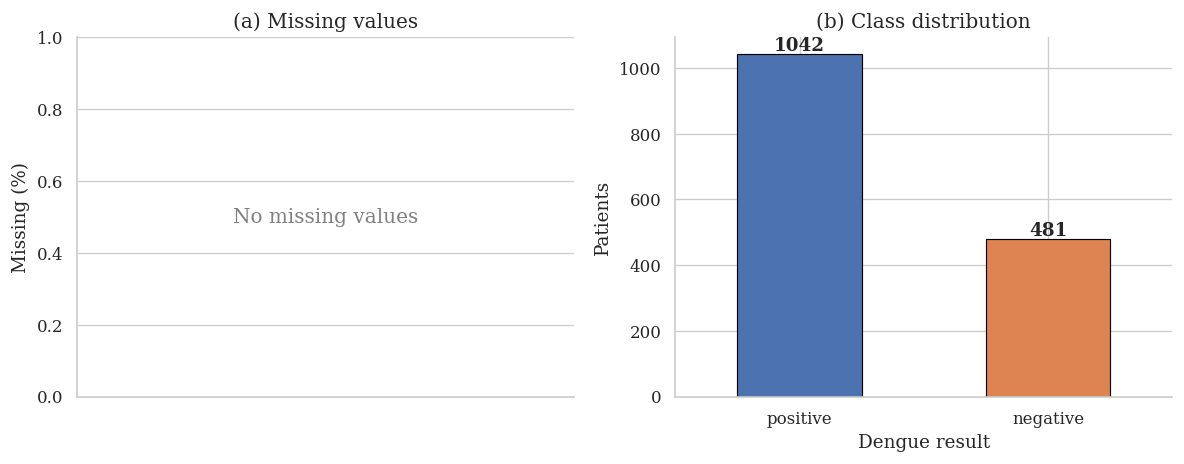

In [6]:
missing_pct = (df.isna().sum() / len(df) * 100).round(3)
print(f'Duplicate rows : {df.duplicated().sum()}')
print(f'Total missing  : {df.isna().sum().sum()}')

class_counts = df['Result'].value_counts()
print('\nClass distribution:')
for c,n in class_counts.items():
    print(f'  {c:<12s}: {n:>4d}  ({n/len(df)*100:5.2f} %)')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Missing-values bar
if missing_pct.sum() == 0:
    axes[0].text(.5,.5,'No missing values',ha='center',va='center',
                 transform=axes[0].transAxes,fontsize=12,color='gray')
    axes[0].set_xticks([])
else:
    missing_pct[missing_pct>0].plot(kind='bar',ax=axes[0],
        color='#C44E52',edgecolor='black',linewidth=.6)
axes[0].set_ylabel('Missing (%)'); axes[0].set_title('(a) Missing values')

# Class distribution
colors = ['#4C72B0','#DD8452']
class_counts.plot(kind='bar',ax=axes[1],color=colors,edgecolor='black',linewidth=.7)
for i,v in enumerate(class_counts.values):
    axes[1].text(i, v + max(class_counts)*.01, str(v), ha='center',fontweight='bold')
axes[1].set_xlabel('Dengue result'); axes[1].set_ylabel('Patients')
axes[1].set_title('(b) Class distribution'); axes[1].set_xticklabels(class_counts.index,rotation=0)

plt.tight_layout(); savefig('fig_01_overview'); plt.show()

  → saved fig_02_correlation_heatmap.png / .pdf


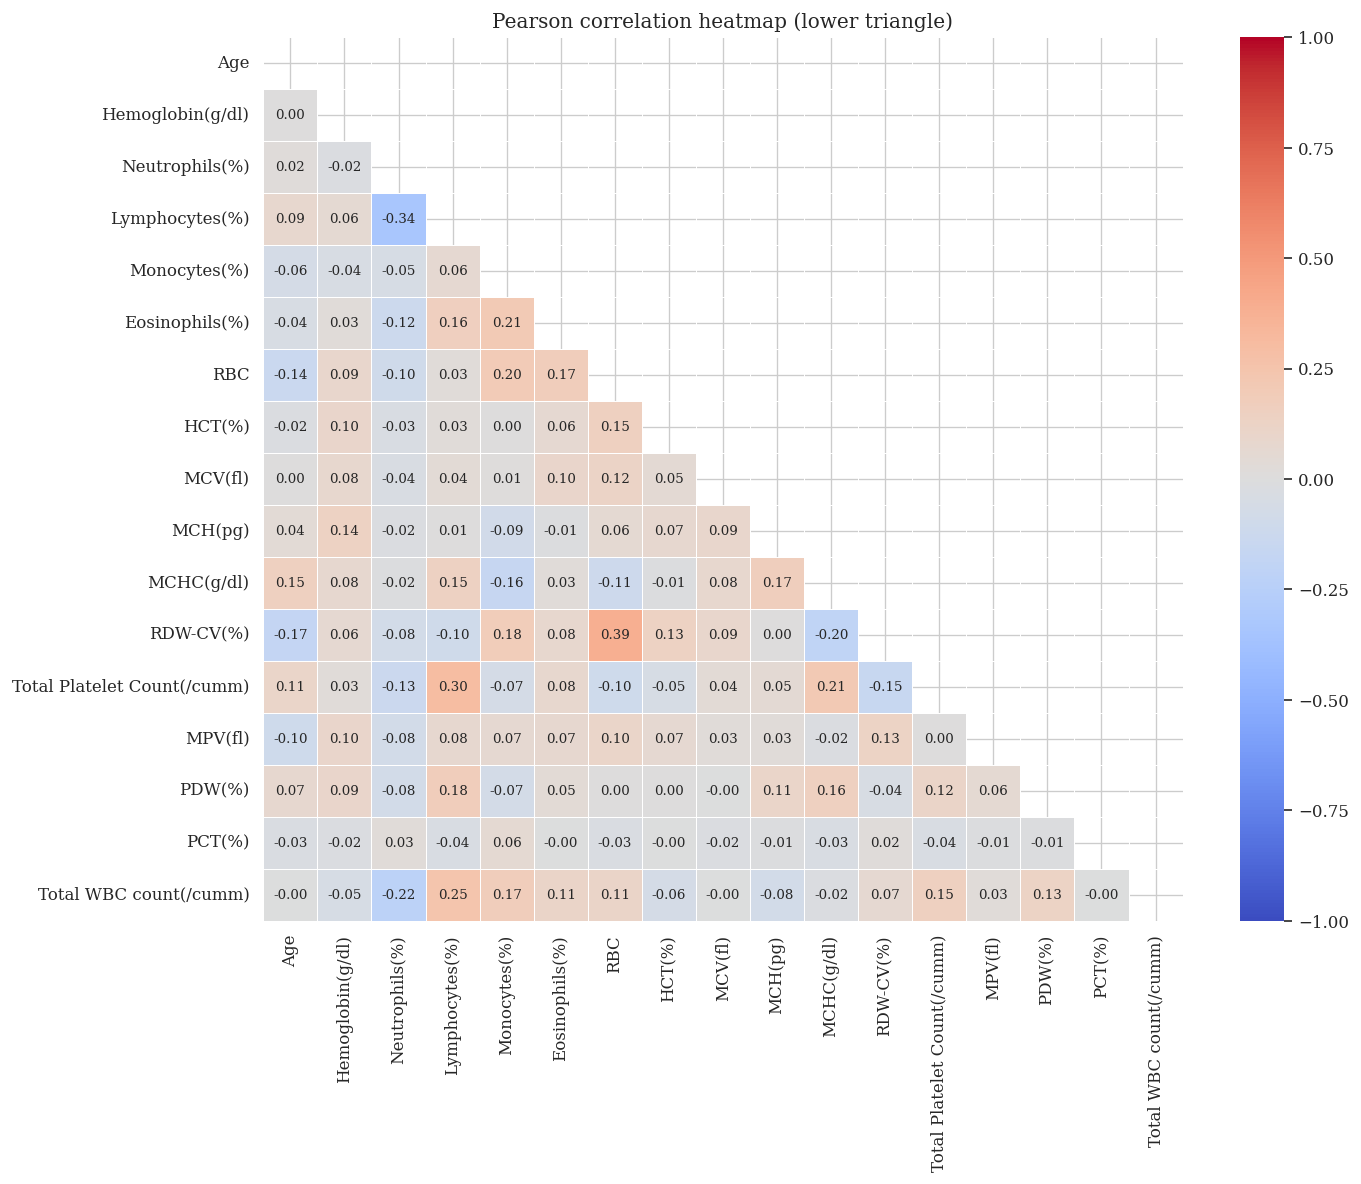

Variance Inflation Factors (VIF > 10 → high multicollinearity):


,Feature,VIF
0,MCHC(g/dl),389.24
1,MCV(fl),250.11
2,MCH(pg),221.89
3,HCT(%),159.83
4,MPV(fl),128.34
5,PDW(%),127.66
6,RDW-CV(%),111.02
7,Neutrophils(%),101.90
8,Lymphocytes(%),99.16
9,Hemoglobin(g/dl),85.34


In [7]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'Result']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12,10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, linewidths=.5, annot_kws={'size':8}, ax=ax)
ax.set_title('Pearson correlation heatmap (lower triangle)')
plt.tight_layout(); savefig('fig_02_correlation_heatmap'); plt.show()

# VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = num_cols
vif_data['VIF']     = [variance_inflation_factor(df[num_cols].values, i)
                       for i in range(len(num_cols))]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
print('Variance Inflation Factors (VIF > 10 → high multicollinearity):')
vif_data.round(2)

  → saved fig_03_feature_distributions.png / .pdf


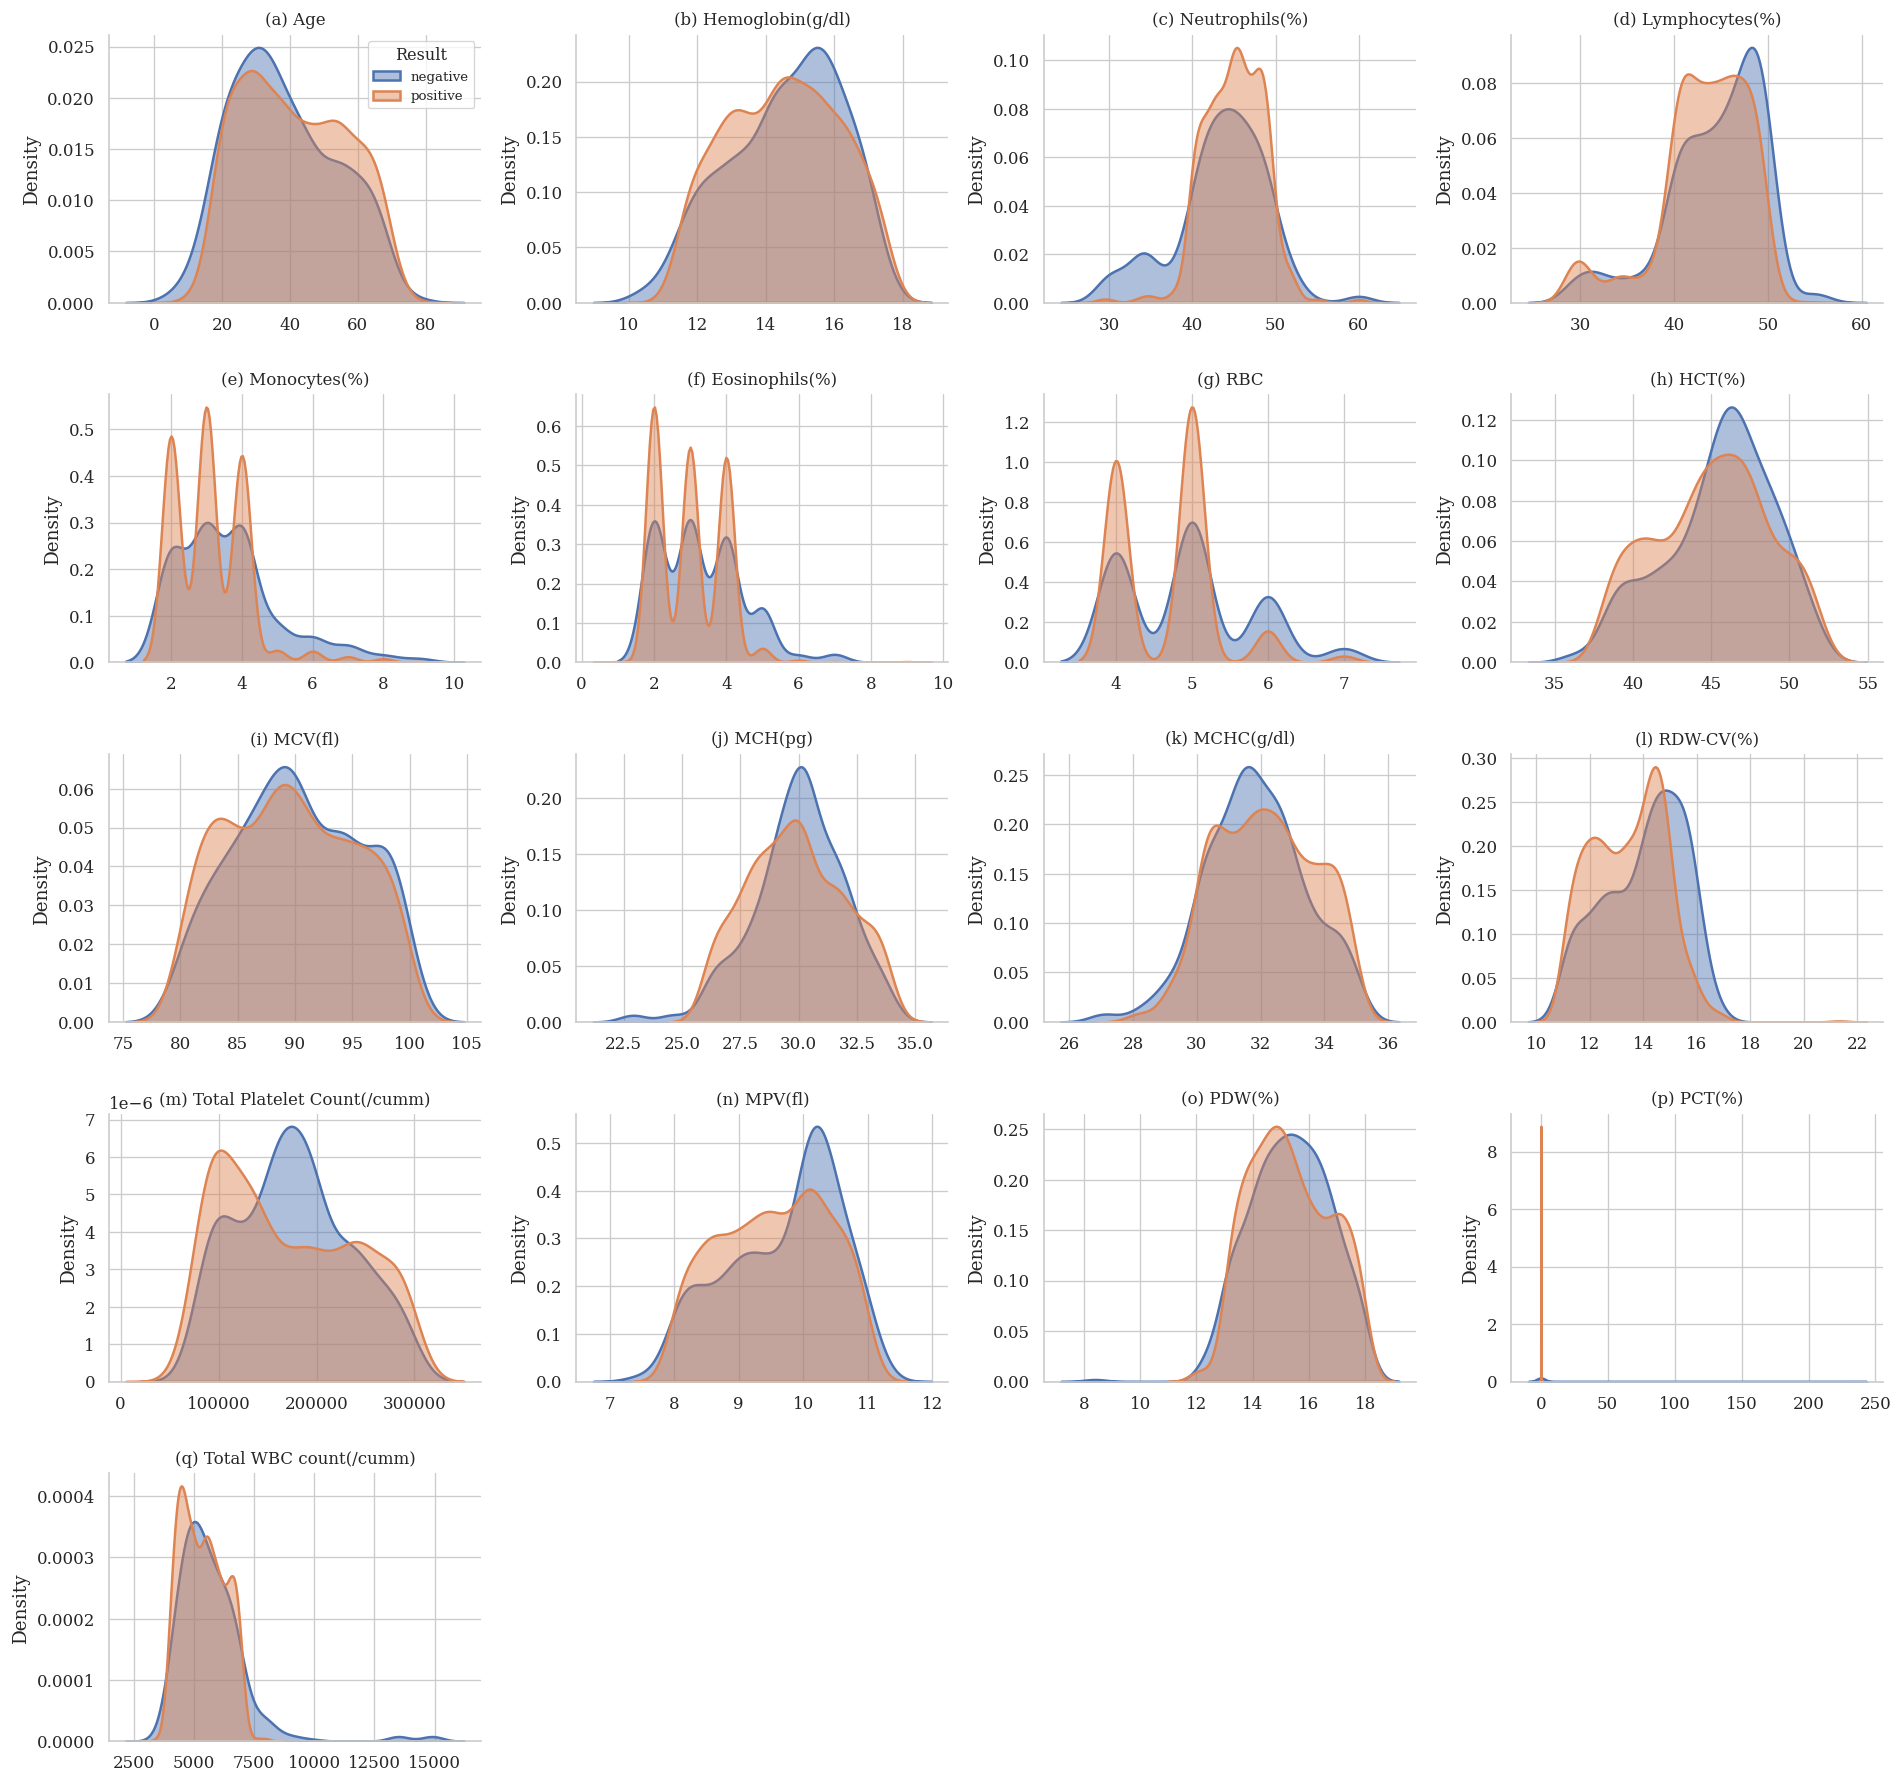

In [8]:
n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()
palette = {'negative':'#4C72B0', 'positive':'#DD8452'}

for i, col in enumerate(num_cols):
    for cls, colour in palette.items():
        subset = df.loc[df['Result']==cls, col]
        sns.kdeplot(subset, ax=axes[i], fill=True, alpha=.45,
                    color=colour, linewidth=1.5, label=cls, common_norm=False)
    axes[i].set_title(f'({chr(97+i)}) {col}', fontsize=10)
    axes[i].set_xlabel(''); axes[i].set_ylabel('Density')
    if i==0: axes[i].legend(title='Result', fontsize=8)
    else:
        leg = axes[i].get_legend()
        if leg: leg.remove()

for j in range(i+1, len(axes)): fig.delaxes(axes[j])
plt.tight_layout(); savefig('fig_03_feature_distributions'); plt.show()

In [9]:
df_enc = df.copy()
gender_le = LabelEncoder().fit(df_enc['Gender'])
result_le = LabelEncoder().fit(df_enc['Result'])
df_enc['Gender'] = gender_le.transform(df_enc['Gender'])
df_enc['Result'] = result_le.transform(df_enc['Result'])

print('Gender mapping :', dict(zip(gender_le.classes_,
                                   gender_le.transform(gender_le.classes_))))
print('Result mapping :', dict(zip(result_le.classes_,
                                   result_le.transform(result_le.classes_))))

# IQR-based outlier removal
iqr_cols = [c for c in ['Neutrophils(%)','Lymphocytes(%)','Monocytes(%)',
                         'Eosinophils(%)','RBC','MCH(pg)','MCHC(g/dl)',
                         'RDW-CV(%)','PDW(%)'] if c in df_enc.columns]
Q1, Q3 = df_enc[iqr_cols].quantile(.25), df_enc[iqr_cols].quantile(.75)
IQR = Q3 - Q1
mask = ~((df_enc[iqr_cols] < Q1-1.5*IQR) | (df_enc[iqr_cols] > Q3+1.5*IQR)).any(axis=1)
df_clean = df_enc.loc[mask].reset_index(drop=True)
print(f'Rows before: {len(df_enc)}  after: {len(df_clean)}'
      f'  removed: {len(df_enc)-len(df_clean)} ({(len(df_enc)-len(df_clean))/len(df_enc)*100:.2f}%)')

Gender mapping : {'Female': np.int64(0), 'Male': np.int64(1)}
Result mapping : {'negative': np.int64(0), 'positive': np.int64(1)}
Rows before: 1523  after: 1372  removed: 151 (9.91%)


In [10]:
X = df_clean.drop(columns=['Result'])
y = df_clean['Result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.20, stratify=y, random_state=RANDOM_STATE)

print(f'Train : {len(X_train)}  (pos={y_train.sum()} neg={(y_train==0).sum()})')
print(f'Test  : {len(X_test)}   (pos={y_test.sum()}  neg={(y_test==0).sum()})')

Train : 1097  (pos=771 neg=326)
Test  : 275   (pos=193  neg=82)


In [11]:
def make_pipeline(estimator, needs_scaling=True):
    '''SMOTEENN is fitted only on the training partition of each CV fold.'''
    steps = []
    if needs_scaling:
        steps.append(('scaler', StandardScaler()))
    steps.append(('resampler', SMOTEENN(random_state=RANDOM_STATE)))
    steps.append(('clf', estimator))
    return ImbPipeline(steps=steps)

In [13]:
models = {
    'KNN'               : (KNeighborsClassifier(n_neighbors=5),          True),
    'Decision Tree'     : (DecisionTreeClassifier(random_state=RANDOM_STATE), False),
    'Random Forest'     : (RandomForestClassifier(n_estimators=300,
                                                   random_state=RANDOM_STATE,
                                                   n_jobs=-1),           False),
    'SVM (RBF)'         : (SVC(kernel='rbf', probability=True,
                               random_state=RANDOM_STATE),               True),
    'Logistic Reg.'     : (LogisticRegression(max_iter=1000,
                                               random_state=RANDOM_STATE), True),
    'Gradient Boosting' : (GradientBoostingClassifier(
                                random_state=RANDOM_STATE),               False),
    'MLP'               : (MLPClassifier(hidden_layer_sizes=(64,32),
                                          max_iter=500,
                                          random_state=RANDOM_STATE),    True),
}

if _HAS_XGB:
    models['XGBoost'] = (XGBClassifier(n_estimators=300, learning_rate=.1,
                                        max_depth=6, eval_metric='logloss',
                                        random_state=RANDOM_STATE, n_jobs=-1),
                         False)
if _HAS_LGB:
    models['LightGBM'] = (LGBMClassifier(n_estimators=300, learning_rate=.05,
                                           max_depth=6,
                                           random_state=RANDOM_STATE,
                                           n_jobs=-1, verbose=-1),       False)
if _HAS_CAT:
    models['CatBoost'] = (CatBoostClassifier(iterations=300, learning_rate=.05,
                                              depth=6,
                                              random_state=RANDOM_STATE,
                                              verbose=0),                False)

print(f'Total models : {len(models)}')
for n in models: print('  •', n)

Total models : 9
  • KNN
  • Decision Tree
  • Random Forest
  • SVM (RBF)
  • Logistic Reg.
  • Gradient Boosting
  • MLP
  • XGBoost
  • LightGBM


In [14]:
scoring = {
    'accuracy' : 'accuracy',
    'precision': 'precision',
    'recall'   : 'recall',
    'f1'       : 'f1',
    'roc_auc'  : 'roc_auc',
}

cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []; cv_fold_scores = {}

for name, (est, scale) in models.items():
    print(f'  CV → {name} …', end='', flush=True)
    pipe  = make_pipeline(est, needs_scaling=scale)
    sc    = cross_validate(pipe, X_train, y_train, cv=cv10,
                           scoring=scoring, n_jobs=-1)
    cv_fold_scores[name] = sc['test_accuracy']
    cv_rows.append({
        'Model'    : name,
        'Accuracy' : f"{sc['test_accuracy'].mean():.4f} ± {sc['test_accuracy'].std():.4f}",
        'Precision': f"{sc['test_precision'].mean():.4f} ± {sc['test_precision'].std():.4f}",
        'Recall'   : f"{sc['test_recall'].mean():.4f} ± {sc['test_recall'].std():.4f}",
        'F1'       : f"{sc['test_f1'].mean():.4f} ± {sc['test_f1'].std():.4f}",
        'ROC-AUC'  : f"{sc['test_roc_auc'].mean():.4f} ± {sc['test_roc_auc'].std():.4f}",
        '_acc_mean': sc['test_accuracy'].mean(),
    })
    print(f"  acc={sc['test_accuracy'].mean():.4f}")

cv_df = (pd.DataFrame(cv_rows)
           .sort_values('_acc_mean', ascending=False)
           .drop(columns=['_acc_mean'])
           .reset_index(drop=True))
cv_df

  CV → KNN …  acc=0.4383
  CV → Decision Tree …  acc=0.6135
  CV → Random Forest …  acc=0.6918
  CV → SVM (RBF) …  acc=0.5014
  CV → Logistic Reg. …  acc=0.4576
  CV → Gradient Boosting …  acc=0.6417
  CV → MLP …  acc=0.5523
  CV → XGBoost …  acc=0.6490
  CV → LightGBM …  acc=0.6408


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.6918 ± 0.0478,0.7671 ± 0.0342,0.8080 ± 0.0568,0.7860 ± 0.0363,0.6344 ± 0.0884
1,XGBoost,0.6490 ± 0.0350,0.7632 ± 0.0348,0.7289 ± 0.0415,0.7446 ± 0.0262,0.6135 ± 0.0713
2,Gradient Boosting,0.6417 ± 0.0514,0.7621 ± 0.0418,0.7160 ± 0.0619,0.7367 ± 0.0405,0.6163 ± 0.0884
3,LightGBM,0.6408 ± 0.0503,0.7541 ± 0.0369,0.7263 ± 0.0551,0.7391 ± 0.0403,0.6076 ± 0.0699
4,Decision Tree,0.6135 ± 0.0495,0.7587 ± 0.0379,0.6601 ± 0.0537,0.7052 ± 0.0422,0.5818 ± 0.0543
5,MLP,0.5523 ± 0.0627,0.7478 ± 0.0409,0.5433 ± 0.0768,0.6280 ± 0.0649,0.5936 ± 0.0464
6,SVM (RBF),0.5014 ± 0.0457,0.7375 ± 0.0459,0.4487 ± 0.0568,0.5569 ± 0.0547,0.5930 ± 0.0502
7,Logistic Reg.,0.4576 ± 0.0388,0.7755 ± 0.0518,0.3242 ± 0.0695,0.4522 ± 0.0709,0.6350 ± 0.0590
8,KNN,0.4383 ± 0.0462,0.7688 ± 0.0762,0.2853 ± 0.0422,0.4158 ± 0.0554,0.6034 ± 0.0524


In [15]:
# Outer 10-fold / inner 5-fold.  We run nested CV only for the top-3 CV models
# to keep runtime reasonable.
top3 = cv_df.head(3)['Model'].tolist()
print('Nested CV for:', top3)

outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
inner_cv  = StratifiedKFold(n_splits=5,  shuffle=True, random_state=RANDOM_STATE)

nested_rows = []
for name in top3:
    est, scale = models[name]
    pipe = make_pipeline(est, needs_scaling=scale)
    # inner GridSearch with a small grid just for the nested wrapper
    param_tiny = {
        'Random Forest' : {'clf__n_estimators': [200, 300]},
        'XGBoost'       : {'clf__n_estimators': [200, 300], 'clf__max_depth': [5,7]},
        'LightGBM'      : {'clf__n_estimators': [200, 300]},
        'CatBoost'      : {'clf__iterations'  : [200, 300]},
        'Gradient Boosting': {'clf__n_estimators':[100,200],'clf__max_depth':[3,5]},
        'SVM (RBF)'     : {'clf__C': [1, 10], 'clf__gamma': ['scale']},
        'MLP'           : {'clf__hidden_layer_sizes': [(64,32),(128,64)]},
        'Logistic Reg.' : {'clf__C': [0.1, 1, 10]},
        'KNN'           : {'clf__n_neighbors': [5, 7]},
        'Decision Tree' : {'clf__max_depth': [None, 10]},
    }
    grid = param_tiny.get(name, {})
    if grid:
        inner_gs = GridSearchCV(pipe, grid, cv=inner_cv,
                                scoring='roc_auc', n_jobs=-1)
    else:
        inner_gs = pipe

    print(f'  Nested CV → {name} …', end='', flush=True)
    nested_scores = cross_val_score(inner_gs, X_train, y_train,
                                    cv=outer_cv, scoring='roc_auc', n_jobs=-1)
    nested_rows.append({'Model': name,
                        'Nested CV ROC-AUC':
                            f'{nested_scores.mean():.4f} ± {nested_scores.std():.4f}'})
    print(f'  {nested_scores.mean():.4f}')

nested_df = pd.DataFrame(nested_rows)
nested_df

Nested CV for: ['Random Forest', 'XGBoost', 'Gradient Boosting']
  Nested CV → Random Forest …  0.6351
  Nested CV → XGBoost …  0.6184
  Nested CV → Gradient Boosting …  0.6195


,Model,Nested CV ROC-AUC
0,Random Forest,0.6351 ± 0.0900
1,XGBoost,0.6184 ± 0.0659
2,Gradient Boosting,0.6195 ± 0.0827


In [16]:
best_model_name = cv_df.iloc[0]['Model']
print(f'Reference model : {best_model_name}')

ref  = cv_fold_scores[best_model_name]
stat_rows = []
for name, arr in cv_fold_scores.items():
    if name == best_model_name: continue
    try:   w, p = stats.wilcoxon(ref, arr)
    except ValueError: w, p = np.nan, np.nan
    stat_rows.append({'Comparison': f'{best_model_name} vs {name}',
                      'W-stat': round(w,3) if not np.isnan(w) else '–',
                      'p-value': round(p,4) if not np.isnan(p) else '–',
                      'Sig. (α=0.05)': 'Yes' if isinstance(p,float) and p<.05 else 'No'})

stat_df = pd.DataFrame(stat_rows)
stat_df

Reference model : Random Forest


,Comparison,W-stat,p-value,Sig. (α=0.05)
0,Random Forest vs KNN,0.0,0.0020,Yes
1,Random Forest vs Decision Tree,0.0,0.0020,Yes
2,Random Forest vs SVM (RBF),0.0,0.0020,Yes
3,Random Forest vs Logistic Reg.,0.0,0.0020,Yes
4,Random Forest vs Gradient Boosting,2.0,0.0059,Yes
5,Random Forest vs MLP,0.0,0.0020,Yes
6,Random Forest vs XGBoost,2.5,0.0078,Yes
7,Random Forest vs LightGBM,1.0,0.0078,Yes


In [17]:
if _HAS_OPTUNA:
    est_obj, needs_scale = models[best_model_name]

    def objective(trial):
        # ── Build param dict per model ────────────────────────────────────────
        if best_model_name == 'Random Forest':
            params = {
                'clf__n_estimators'     : trial.suggest_int('n_est', 100, 800, step=100),
                'clf__max_depth'        : trial.suggest_categorical('max_d', [None,10,20,30]),
                'clf__min_samples_split': trial.suggest_int('mss', 2, 20),
                'clf__min_samples_leaf' : trial.suggest_int('msl', 1, 10),
                'clf__max_features'     : trial.suggest_categorical('mf',['sqrt','log2',None]),
            }
        elif best_model_name == 'XGBoost':
            params = {
                'clf__n_estimators'  : trial.suggest_int('n_est', 100, 600, step=100),
                'clf__learning_rate' : trial.suggest_float('lr', 0.01, 0.3, log=True),
                'clf__max_depth'     : trial.suggest_int('max_d', 3, 10),
                'clf__subsample'     : trial.suggest_float('ss', .5, 1.),
                'clf__colsample_bytree': trial.suggest_float('cb', .5, 1.),
                'clf__reg_alpha'     : trial.suggest_float('ra', 1e-5, 10., log=True),
                'clf__reg_lambda'    : trial.suggest_float('rl', 1e-5, 10., log=True),
            }
        elif best_model_name == 'LightGBM':
            params = {
                'clf__n_estimators'   : trial.suggest_int('n_est', 100, 600, step=100),
                'clf__learning_rate'  : trial.suggest_float('lr', 0.01, 0.3, log=True),
                'clf__max_depth'      : trial.suggest_int('max_d', 3, 10),
                'clf__num_leaves'     : trial.suggest_int('nl', 20, 100),
                'clf__reg_alpha'      : trial.suggest_float('ra', 1e-5, 10., log=True),
                'clf__reg_lambda'     : trial.suggest_float('rl', 1e-5, 10., log=True),
                'clf__min_child_samples': trial.suggest_int('mcs', 5, 30),
            }
        elif best_model_name == 'CatBoost':
            params = {
                'clf__iterations'   : trial.suggest_int('n_est', 100, 600, step=100),
                'clf__learning_rate': trial.suggest_float('lr', 0.01, 0.3, log=True),
                'clf__depth'        : trial.suggest_int('depth', 3, 10),
                'clf__l2_leaf_reg'  : trial.suggest_float('l2', 1., 10.),
            }
        elif best_model_name == 'Gradient Boosting':
            params = {
                'clf__n_estimators'  : trial.suggest_int('n_est', 100, 500, step=100),
                'clf__learning_rate' : trial.suggest_float('lr', 0.01, 0.3, log=True),
                'clf__max_depth'     : trial.suggest_int('max_d', 2, 8),
                'clf__subsample'     : trial.suggest_float('ss', .5, 1.),
            }
        elif best_model_name == 'SVM (RBF)':
            params = {
                'clf__C'    : trial.suggest_float('C', 0.01, 100., log=True),
                'clf__gamma': trial.suggest_float('gamma', 1e-4, 1., log=True),
            }
        else:
            # fallback: no HPO
            params = {}

        tune_pipe = make_pipeline(est_obj, needs_scaling=needs_scale)
        if params:
            tune_pipe.set_params(**params)
        cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        sc  = cross_val_score(tune_pipe, X_train, y_train,
                              cv=cv5, scoring='roc_auc', n_jobs=-1)
        return sc.mean()

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=80, show_progress_bar=True)

    print(f'Best ROC-AUC (Optuna) : {study.best_value:.4f}')
    print(f'Best params           : {study.best_params}')

    # Rebuild best pipeline with found params
    best_pipe = make_pipeline(est_obj, needs_scaling=needs_scale)
    if study.best_params:
        # Map short param names back to pipeline param names
        param_map = {
            'n_est' :'clf__n_estimators','lr':'clf__learning_rate',
            'max_d' :'clf__max_depth','mss':'clf__min_samples_split',
            'msl'   :'clf__min_samples_leaf','mf':'clf__max_features',
            'ss'    :'clf__subsample','cb':'clf__colsample_bytree',
            'ra'    :'clf__reg_alpha','rl':'clf__reg_lambda',
            'nl'    :'clf__num_leaves','mcs':'clf__min_child_samples',
            'depth' :'clf__depth','l2':'clf__l2_leaf_reg',
            'C'     :'clf__C','gamma':'clf__gamma',
        }
        mapped = {param_map.get(k,k): v for k,v in study.best_params.items()}
        best_pipe.set_params(**mapped)
    best_pipe.fit(X_train, y_train)
    print('Best pipeline refitted on full training set.')

else:
    # Fallback to GridSearchCV if Optuna not available
    print('Optuna not found — falling back to GridSearchCV.')
    param_grids = {
        'Random Forest': {'clf__n_estimators':[200,300,500],
                          'clf__max_depth':[None,10,20]},
        'XGBoost'      : {'clf__n_estimators':[200,300],'clf__max_depth':[5,7],
                          'clf__learning_rate':[.05,.1]},
        'LightGBM'     : {'clf__n_estimators':[200,300],'clf__learning_rate':[.05,.1]},
    }
    est_obj, needs_scale = models[best_model_name]
    tune_pipe = make_pipeline(est_obj, needs_scaling=needs_scale)
    grid = param_grids.get(best_model_name, {})
    if grid:
        gs = GridSearchCV(tune_pipe, grid, scoring='roc_auc',
                          cv=StratifiedKFold(5,shuffle=True,
                                             random_state=RANDOM_STATE),
                          n_jobs=-1)
        gs.fit(X_train, y_train)
        best_pipe = gs.best_estimator_
        print(f'Best ROC-AUC : {gs.best_score_:.4f}')
        print(f'Best params  : {gs.best_params_}')
    else:
        tune_pipe.fit(X_train, y_train)
        best_pipe = tune_pipe

Optuna not found — falling back to GridSearchCV.
Best ROC-AUC : 0.6436
Best params  : {'clf__max_depth': 10, 'clf__n_estimators': 200}


In [18]:
N_BOOT = 2000

def bootstrap_ci(y_true, y_pred, y_prob, metric_fn, n=N_BOOT, ci=.95,
                 needs_prob=False):
    rng = np.random.default_rng(RANDOM_STATE)
    vals = []
    for _ in range(n):
        idx = rng.integers(0, len(y_true), len(y_true))
        yt  = np.array(y_true)[idx]
        yp  = np.array(y_pred)[idx]
        ypr = np.array(y_prob)[idx]
        if len(np.unique(yt)) < 2: continue
        try:
            v = metric_fn(yt, ypr) if needs_prob else metric_fn(yt, yp)
            vals.append(v)
        except Exception: pass
    lo = np.percentile(vals, (1-ci)/2*100)
    hi = np.percentile(vals, (1-(1-ci)/2)*100)
    return lo, hi

def evaluate(pipe, X_te, y_te, name, compute_ci=False):
    y_pred = pipe.predict(X_te)
    try:   y_prob = pipe.predict_proba(X_te)[:,1]
    except Exception: y_prob = pipe.decision_function(X_te)

    row = {
        'Model'     : name,
        'Accuracy'  : accuracy_score(y_te, y_pred),
        'Precision' : precision_score(y_te, y_pred, zero_division=0),
        'Recall'    : recall_score(y_te, y_pred),
        'F1'        : f1_score(y_te, y_pred),
        'Specificity': confusion_matrix(y_te, y_pred).ravel()[0] /
                       (confusion_matrix(y_te, y_pred).ravel()[0] +
                        confusion_matrix(y_te, y_pred).ravel()[1] + 1e-9),
        'MCC'       : matthews_corrcoef(y_te, y_pred),
        "Cohen's κ" : cohen_kappa_score(y_te, y_pred),
        'ROC-AUC'   : roc_auc_score(y_te, y_prob),
        'PR-AUC'    : average_precision_score(y_te, y_prob),
        'Brier'     : brier_score_loss(y_te, y_prob),
        '_y_pred'   : y_pred,
        '_y_prob'   : y_prob,
    }

    if compute_ci:
        lo, hi = bootstrap_ci(y_te, y_pred, y_prob,
                               roc_auc_score, needs_prob=True)
        row['ROC-AUC 95% CI'] = f'[{lo:.4f}, {hi:.4f}]'
        lo2, hi2 = bootstrap_ci(y_te, y_pred, y_prob, f1_score)
        row['F1 95% CI']      = f'[{lo2:.4f}, {hi2:.4f}]'

    return row

# Fit all baselines
test_results = []; stored_preds = {}
for name, (est, scale) in models.items():
    pipe = make_pipeline(est, needs_scaling=scale)
    pipe.fit(X_train, y_train)
    res = evaluate(pipe, X_test, y_test, name)
    stored_preds[name] = (res.pop('_y_pred'), res.pop('_y_prob'))
    test_results.append(res)

# Best tuned model
res_tuned = evaluate(best_pipe, X_test, y_test,
                     f'{best_model_name} (tuned)', compute_ci=True)
stored_preds[f'{best_model_name} (tuned)'] = (
    res_tuned.pop('_y_pred'), res_tuned.pop('_y_prob'))
test_results.append(res_tuned)

test_df = (pd.DataFrame(test_results)
             .sort_values('ROC-AUC', ascending=False)
             .reset_index(drop=True))

display_cols = ['Model','Accuracy','Precision','Recall','Specificity',
                'F1','MCC',"Cohen's κ",'ROC-AUC','PR-AUC','Brier']
if 'ROC-AUC 95% CI' in test_df.columns:
    display_cols += ['ROC-AUC 95% CI','F1 95% CI']
test_df[display_cols].round(4)

,Model,Accuracy,Precision,Recall,Specificity,F1,MCC,Cohen's κ,ROC-AUC,PR-AUC,Brier,ROC-AUC 95% CI,F1 95% CI
0,MLP,0.5891,0.7632,0.6010,0.5610,0.6725,0.1491,0.1416,0.6217,0.7622,0.3527,NaN,NaN
1,Random Forest,0.6800,0.7561,0.8031,0.3902,0.7789,0.2031,0.2018,0.6186,0.7666,0.2134,NaN,NaN
2,Random Forest (tuned),0.6691,0.7500,0.7927,0.3780,0.7708,0.1785,0.1776,0.6161,0.7638,0.2152,"[0.5375, 0.6907]","[0.7219, 0.8136]"
3,Gradient Boosting,0.6145,0.7458,0.6839,0.4512,0.7135,0.1291,0.1280,0.6081,0.7415,0.2637,NaN,NaN
4,LightGBM,0.6327,0.7556,0.7047,0.4634,0.7292,0.1617,0.1607,0.6074,0.7440,0.2956,NaN,NaN
5,SVM (RBF),0.5818,0.7532,0.6010,0.5366,0.6686,0.1268,0.1211,0.6012,0.7588,0.2856,NaN,NaN
6,XGBoost,0.6327,0.7500,0.7150,0.4390,0.7321,0.1498,0.1493,0.5955,0.7326,0.2877,NaN,NaN
7,KNN,0.4764,0.7579,0.3731,0.7195,0.5000,0.0891,0.0689,0.5755,0.7361,0.3975,NaN,NaN
8,Logistic Reg.,0.4364,0.7262,0.3161,0.7195,0.4404,0.0353,0.0257,0.5596,0.7195,0.3426,NaN,NaN
9,Decision Tree,0.6073,0.7401,0.6788,0.4390,0.7081,0.1125,0.1115,0.5589,0.7278,0.3927,NaN,NaN


In [19]:
# DeLong's method (Hanley-McNeil structural component approach)
def delong_roc_variance(ground_truth, predictions):
    '''Returns theta (AUC) and variance for DeLong's test.'''
    order = np.argsort(-predictions)
    label_1_count = int(ground_truth.sum())
    label_0_count = len(ground_truth) - label_1_count
    sorted_labels = ground_truth[order]
    # placement values
    m  = label_1_count
    n  = label_0_count
    pos_idx = np.where(sorted_labels == 1)[0]
    neg_idx = np.where(sorted_labels == 0)[0]
    x  = predictions[order][pos_idx]
    y  = predictions[order][neg_idx]
    # Wilcoxon / Mann-Whitney form
    V10 = np.array([(x_i > y).mean() + .5*(x_i == y).mean() for x_i in x])
    V01 = np.array([(x > y_j).mean() + .5*(x == y_j).mean() for y_j in y])
    theta = V10.mean()
    s10   = (V10 - theta).var() / m
    s01   = (V01 - theta).var() / n
    var   = s10 + s01
    return theta, var

y_te_arr = np.array(y_test)
best_name_tuned = f'{best_model_name} (tuned)'
_, y_prob_best  = stored_preds[best_name_tuned]

delong_rows = []
for name, (_, y_prob) in stored_preds.items():
    if name == best_name_tuned: continue
    t1, v1 = delong_roc_variance(y_te_arr, y_prob_best)
    t2, v2 = delong_roc_variance(y_te_arr, np.array(y_prob))
    # Covariance (assumes independent — conservative)
    se = np.sqrt(v1 + v2)
    z  = (t1 - t2) / (se + 1e-12)
    p  = 2 * (1 - stats.norm.cdf(abs(z)))
    delong_rows.append({'Comparison'      : f'{best_name_tuned} vs {name}',
                        'ΔAUC'            : round(t1-t2, 4),
                        'z-stat'          : round(z, 3),
                        'p-value'         : round(p, 4),
                        'Sig. (α=0.05)'   : 'Yes' if p < .05 else 'No'})

delong_df = pd.DataFrame(delong_rows)
delong_df

,Comparison,ΔAUC,z-stat,p-value,Sig. (α=0.05)
0,Random Forest (tuned) vs KNN,0.0405,0.747,0.4551,No
1,Random Forest (tuned) vs Decision Tree,0.0572,1.128,0.2593,No
2,Random Forest (tuned) vs Random Forest,-0.0025,-0.045,0.9641,No
3,Random Forest (tuned) vs SVM (RBF),0.0149,0.270,0.7868,No
4,Random Forest (tuned) vs Logistic Reg.,0.0564,1.008,0.3135,No
5,Random Forest (tuned) vs Gradient Boosting,0.0080,0.145,0.8851,No
6,Random Forest (tuned) vs MLP,-0.0056,-0.102,0.9185,No
7,Random Forest (tuned) vs XGBoost,0.0206,0.366,0.7142,No
8,Random Forest (tuned) vs LightGBM,0.0087,0.155,0.8771,No


  → saved fig_04_confusion_matrix.png / .pdf


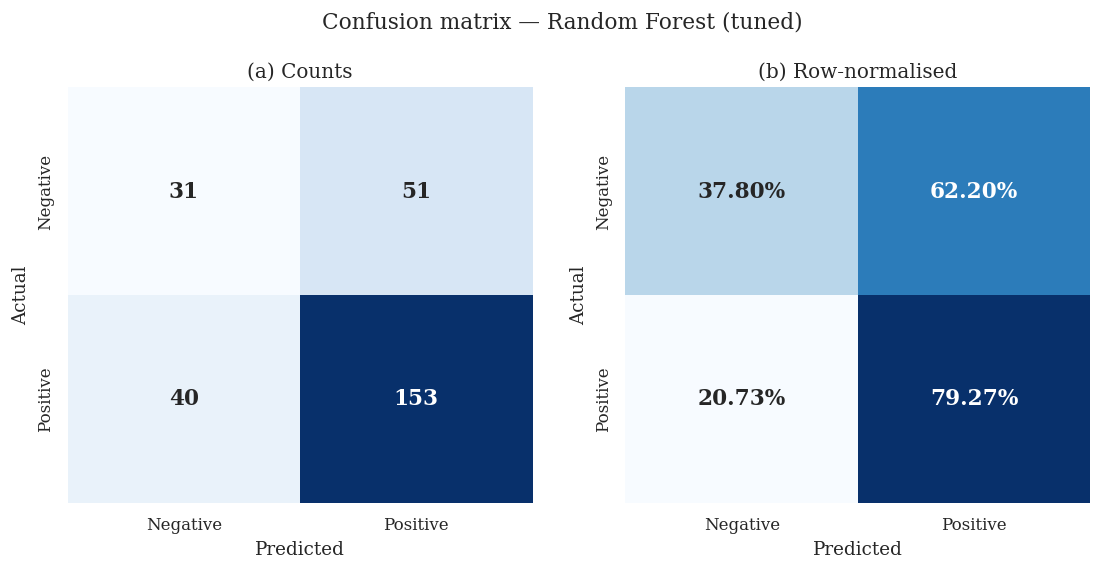

              precision    recall  f1-score   support

    Negative     0.4366    0.3780    0.4052        82
    Positive     0.7500    0.7927    0.7708       193

    accuracy                         0.6691       275
   macro avg     0.5933    0.5854    0.5880       275
weighted avg     0.6566    0.6691    0.6618       275



In [20]:
y_pred_best, y_prob_best = stored_preds[f'{best_model_name} (tuned)']
cm      = confusion_matrix(y_test, y_pred_best)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2%'],
        ['(a) Counts', '(b) Row-normalised']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=['Negative','Positive'],
                yticklabels=['Negative','Positive'],
                cbar=False, annot_kws={'size':13,'weight':'bold'}, ax=ax)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle(f'Confusion matrix — {best_model_name} (tuned)', y=1.02, fontsize=13)
savefig('fig_04_confusion_matrix'); plt.show()
print(classification_report(y_test, y_pred_best,
      target_names=['Negative','Positive'], digits=4))

  → saved fig_05_roc_pr_curves.png / .pdf


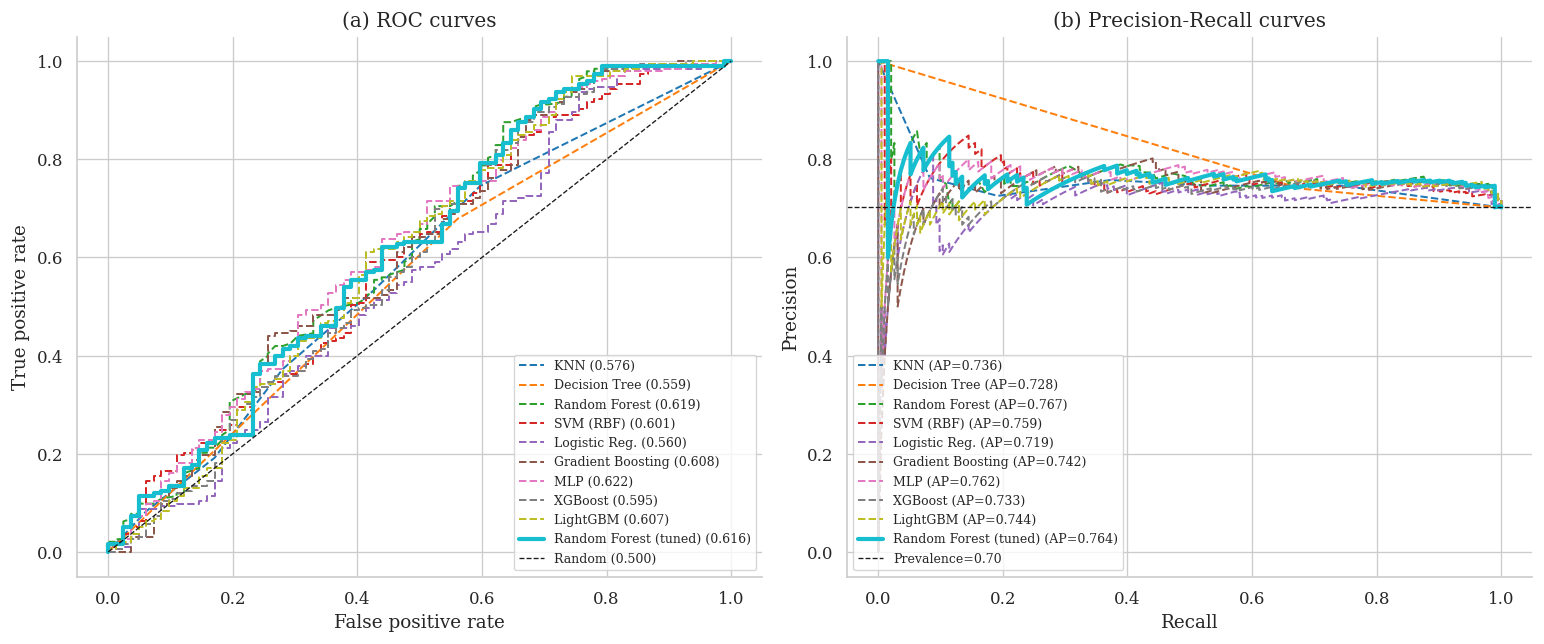

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
colors = sns.color_palette('tab10', n_colors=len(stored_preds))
baseline_pr = (y_test==1).mean()

for (name, (yp, yprob)), col in zip(stored_preds.items(), colors):
    lw   = 2.5 if 'tuned' in name else 1.2
    ls   = '-' if 'tuned' in name else '--'
    fpr, tpr, _ = roc_curve(y_test, yprob)
    auc_v = roc_auc_score(y_test, yprob)
    axes[0].plot(fpr, tpr, label=f'{name} ({auc_v:.3f})',
                 color=col, lw=lw, ls=ls)

    prec, rec, _ = precision_recall_curve(y_test, yprob)
    ap = average_precision_score(y_test, yprob)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})',
                 color=col, lw=lw, ls=ls)

axes[0].plot([0,1],[0,1],'k--',lw=.8,label='Random (0.500)')
axes[0].set(xlabel='False positive rate', ylabel='True positive rate',
            title='(a) ROC curves'); axes[0].legend(loc='lower right',fontsize=7.5)

axes[1].axhline(baseline_pr,color='k',ls='--',lw=.8,
                label=f'Prevalence={baseline_pr:.2f}')
axes[1].set(xlabel='Recall',ylabel='Precision',title='(b) Precision-Recall curves')
axes[1].legend(loc='lower left',fontsize=7.5)

plt.tight_layout(); savefig('fig_05_roc_pr_curves'); plt.show()

  → saved fig_06_calibration_curves.png / .pdf


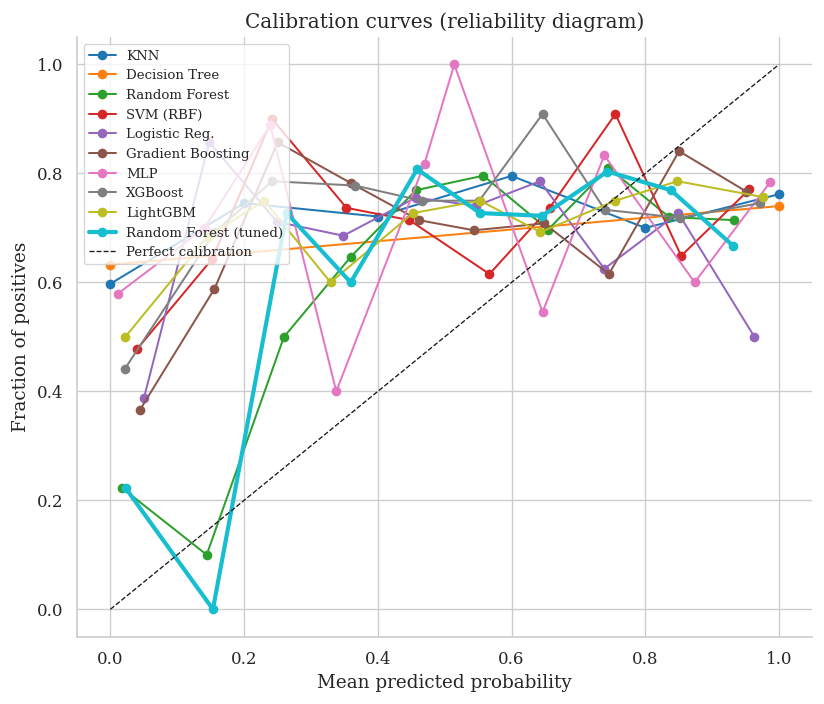

Brier scores (lower = better):
  KNN                           : 0.3975
  Decision Tree                 : 0.3927
  Random Forest                 : 0.2134
  SVM (RBF)                     : 0.2856
  Logistic Reg.                 : 0.3426
  Gradient Boosting             : 0.2637
  MLP                           : 0.3527
  XGBoost                       : 0.2877
  LightGBM                      : 0.2956
  Random Forest (tuned)         : 0.2152


In [22]:
fig, ax = plt.subplots(figsize=(7, 6))
colors  = sns.color_palette('tab10', n_colors=len(stored_preds))

for (name, (_, yprob)), col in zip(stored_preds.items(), colors):
    try:
        frac_pos, mean_pred = calibration_curve(y_test, yprob, n_bins=10)
        lw = 2.5 if 'tuned' in name else 1.2
        ax.plot(mean_pred, frac_pos, marker='o', lw=lw, label=name, color=col)
    except Exception: pass

ax.plot([0,1],[0,1],'k--',lw=.8,label='Perfect calibration')
ax.set(xlabel='Mean predicted probability',
       ylabel='Fraction of positives',
       title='Calibration curves (reliability diagram)')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); savefig('fig_06_calibration_curves'); plt.show()
print('Brier scores (lower = better):')
for r in test_results:
    if 'Brier' in r:
        print(f"  {r['Model']:<30s}: {r['Brier']:.4f}")

  → saved fig_07_permutation_importance.png / .pdf


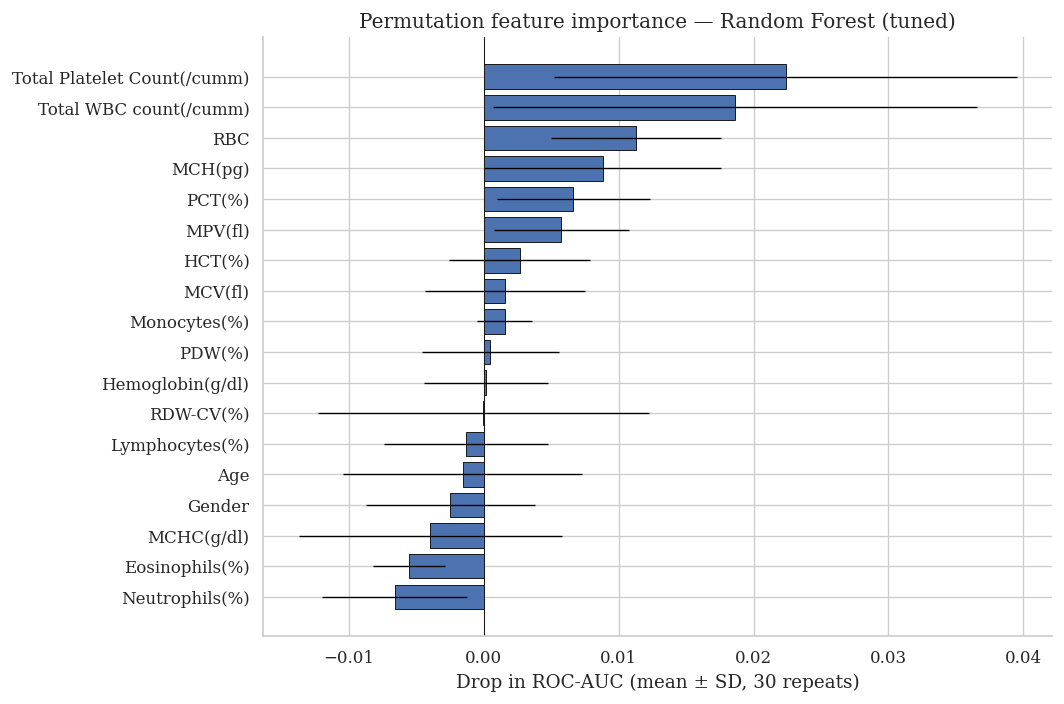

,Feature,Importance,Std,CI_lo,CI_hi
17,Total Platelet Count(/cumm),0.0224,0.0171,-0.0015,0.0561
16,Total WBC count(/cumm),0.0186,0.0180,-0.0094,0.0539
15,RBC,0.0113,0.0063,0.0000,0.0223
14,MCH(pg),0.0088,0.0088,-0.0047,0.0277
13,PCT(%),0.0066,0.0057,-0.0021,0.0158
12,MPV(fl),0.0057,0.0050,-0.0029,0.0140
11,HCT(%),0.0026,0.0053,-0.0071,0.0111
10,MCV(fl),0.0015,0.0059,-0.0086,0.0124
9,Monocytes(%),0.0015,0.0020,-0.0018,0.0060
8,PDW(%),0.0005,0.0051,-0.0081,0.0093


In [23]:
perm = permutation_importance(
    best_pipe, X_test, y_test, n_repeats=30,
    random_state=RANDOM_STATE, n_jobs=-1, scoring='roc_auc')

perm_df = (pd.DataFrame({
    'Feature'   : X_test.columns,
    'Importance': perm.importances_mean,
    'Std'       : perm.importances_std,
    'CI_lo'     : np.percentile(perm.importances, 2.5,  axis=1),
    'CI_hi'     : np.percentile(perm.importances, 97.5, axis=1),
}).sort_values('Importance', ascending=True)
  .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(perm_df['Feature'], perm_df['Importance'],
        xerr=perm_df['Std'], color='#4C72B0', edgecolor='black',
        linewidth=.5, error_kw={'ecolor':'black','elinewidth':.8})
ax.set_xlabel('Drop in ROC-AUC (mean ± SD, 30 repeats)')
ax.set_title(f'Permutation feature importance — {best_model_name} (tuned)')
ax.axvline(0, color='k', lw=.6)
plt.tight_layout(); savefig('fig_07_permutation_importance'); plt.show()

perm_df.sort_values('Importance',ascending=False).round(4)

  → saved fig_08a_shap_beeswarm.png / .pdf


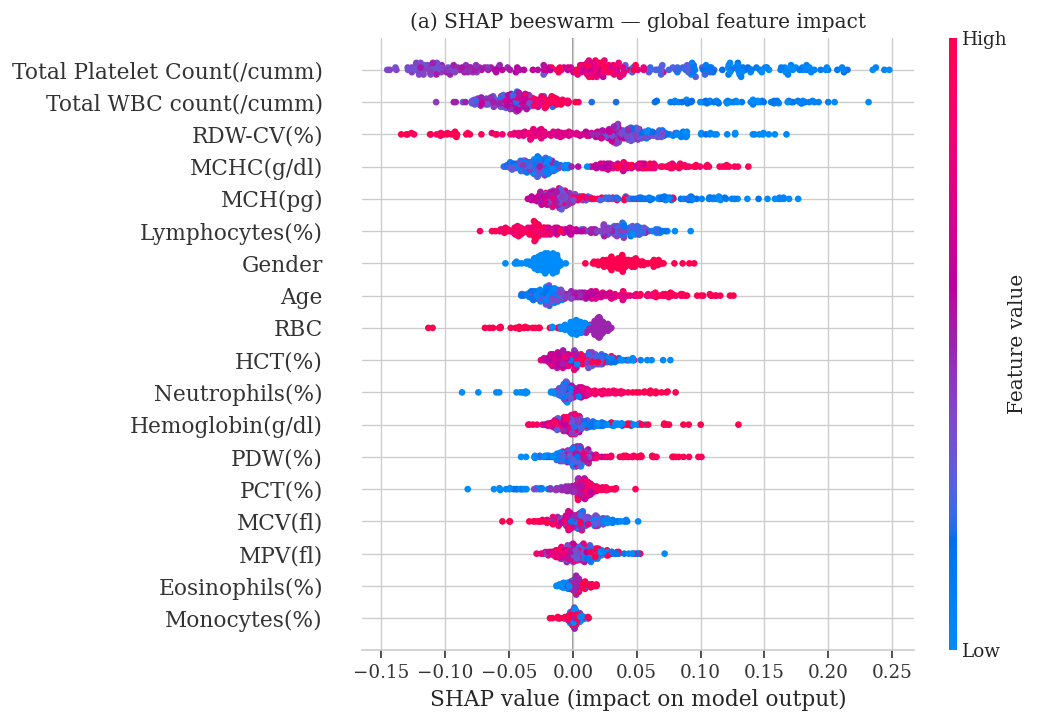

  → saved fig_08b_shap_bar.png / .pdf


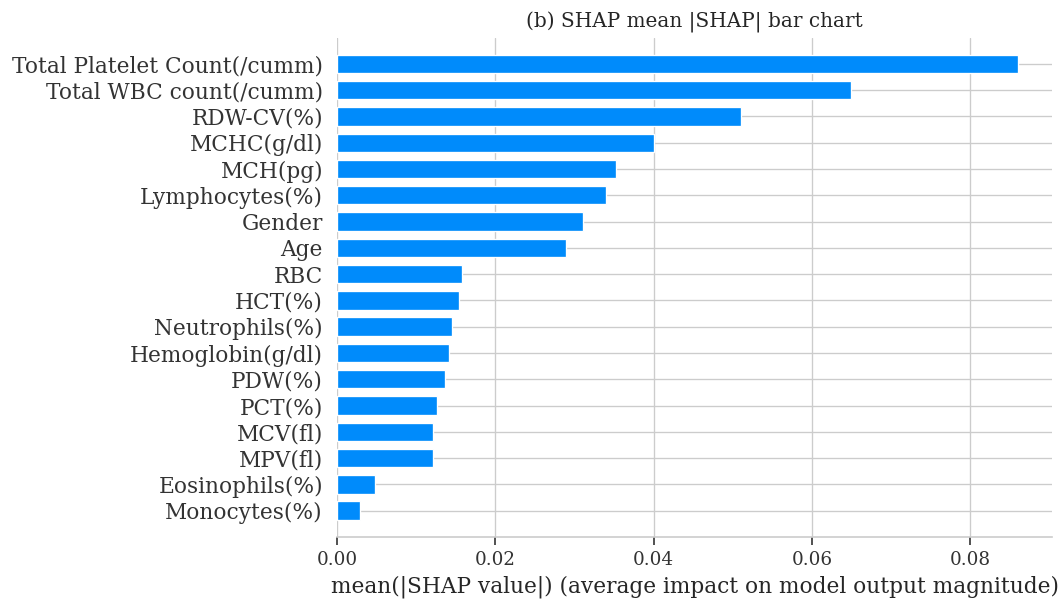

  → saved fig_08c_shap_dependence.png / .pdf


<Figure size 840x600 with 0 Axes>

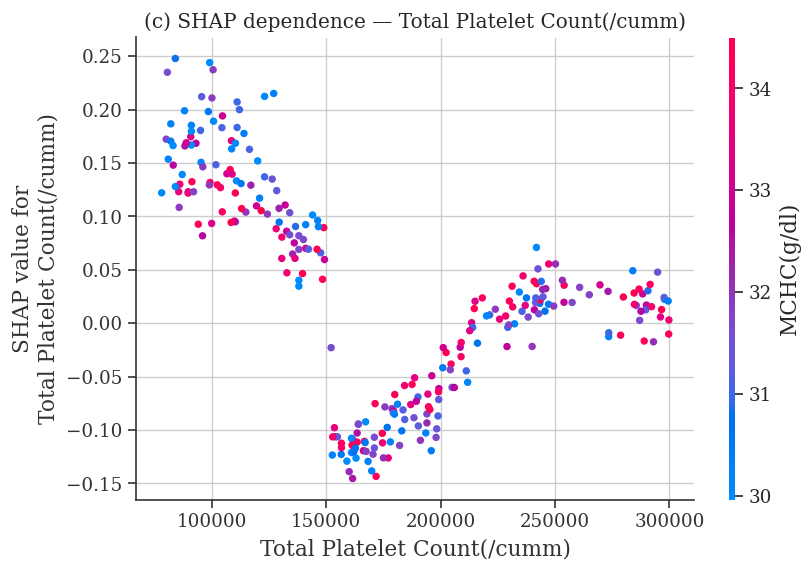

  → saved fig_08d_shap_waterfall.png / .pdf


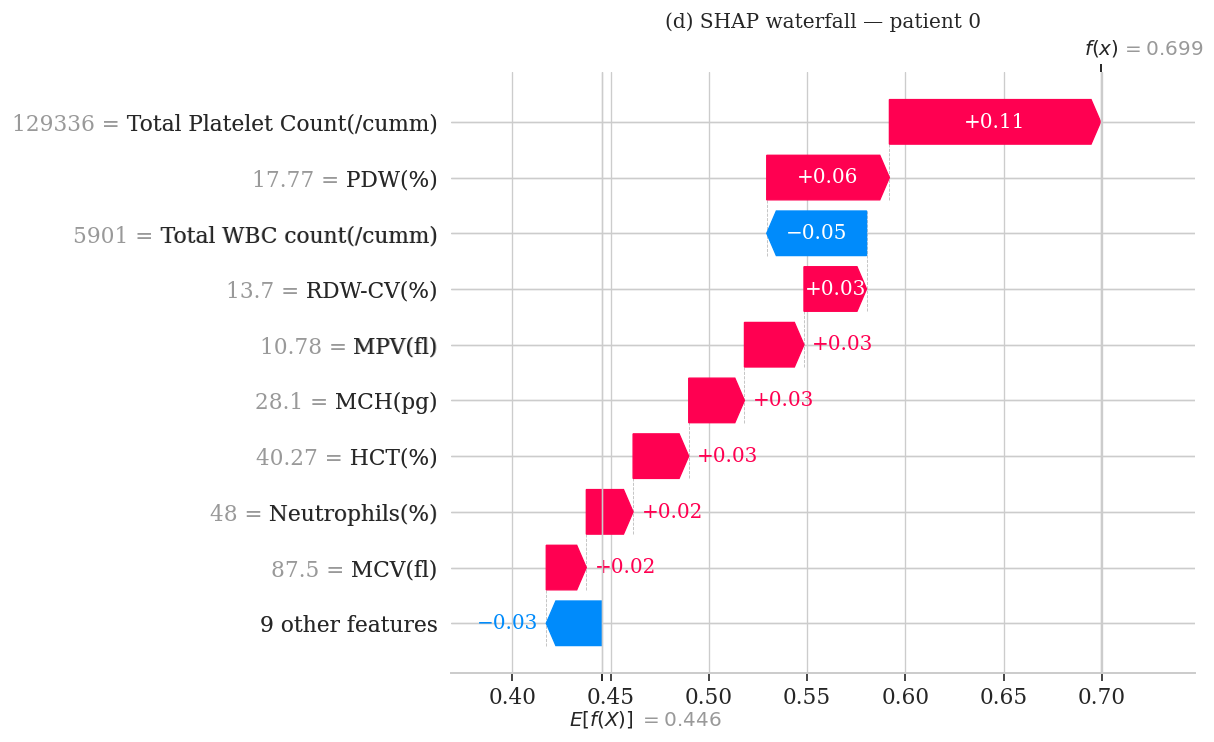

In [24]:
if _HAS_SHAP:
    final_clf  = best_pipe.named_steps['clf']
    X_test_proc = X_test.copy()
    if 'scaler' in best_pipe.named_steps:
        X_test_proc = pd.DataFrame(
            best_pipe.named_steps['scaler'].transform(X_test_proc),
            columns=X_test.columns, index=X_test.index)

    tree_models = ['Random Forest','Decision Tree','XGBoost',
                   'Gradient Boosting','LightGBM','CatBoost']

    if best_model_name in tree_models:
        explainer  = shap.TreeExplainer(final_clf)
        shap_vals  = explainer.shap_values(X_test_proc)
        if isinstance(shap_vals, list): shap_vals = shap_vals[1]
        if shap_vals.ndim == 3:         shap_vals = shap_vals[:,:,1]
        exp_val = (explainer.expected_value[1]
                   if isinstance(explainer.expected_value,(list,np.ndarray))
                   else explainer.expected_value)
    else:
        bg = shap.sample(X_test_proc, min(100,len(X_test_proc)),
                         random_state=RANDOM_STATE)
        explainer = shap.KernelExplainer(final_clf.predict_proba, bg)
        shap_vals = explainer.shap_values(X_test_proc, nsamples=200)
        if isinstance(shap_vals,list): shap_vals = shap_vals[1]
        exp_val   = (explainer.expected_value[1]
                     if isinstance(explainer.expected_value,(list,np.ndarray))
                     else explainer.expected_value)

    # (a) Beeswarm
    plt.figure(figsize=(9,6))
    shap.summary_plot(shap_vals, X_test_proc, show=False, plot_size=None)
    plt.title('(a) SHAP beeswarm — global feature impact')
    savefig('fig_08a_shap_beeswarm'); plt.show()

    # (b) Bar
    plt.figure(figsize=(9,5))
    shap.summary_plot(shap_vals, X_test_proc, plot_type='bar',
                      show=False, plot_size=None)
    plt.title('(b) SHAP mean |SHAP| bar chart')
    savefig('fig_08b_shap_bar'); plt.show()

    # (c) Dependence plot — top feature
    top_feat = X_test.columns[np.abs(shap_vals).mean(0).argmax()]
    plt.figure(figsize=(7,5))
    shap.dependence_plot(top_feat, shap_vals, X_test_proc,
                         show=False, dot_size=20)
    plt.title(f'(c) SHAP dependence — {top_feat}')
    savefig('fig_08c_shap_dependence'); plt.show()

    # (d) Waterfall — first test patient
    shap_exp = shap.Explanation(values=shap_vals[0],
                                 base_values=exp_val,
                                 data=X_test_proc.iloc[0],
                                 feature_names=X_test.columns.tolist())
    plt.figure(figsize=(9,5))
    shap.plots.waterfall(shap_exp, show=False)
    plt.title('(d) SHAP waterfall — patient 0')
    savefig('fig_08d_shap_waterfall'); plt.show()

    # Force plot (HTML in notebook)
    shap.initjs()
    display(shap.force_plot(exp_val, shap_vals[0], X_test_proc.iloc[0]))

else:
    print('Install SHAP:  pip install shap')

In [29]:
if _HAS_LIME:
    lime_exp = lime_tabular.LimeTabularExplainer(
        training_data      = X_train.values,
        feature_names      = X_train.columns.tolist(),
        class_names        = result_le.classes_.tolist(),
        mode               = 'classification',
        discretize_continuous = True,
        random_state       = RANDOM_STATE)

    for sample_idx in [0, 1, 2]:   # explain 3 representative patients
        expl = lime_exp.explain_instance(
            X_test.iloc[sample_idx].values,
            best_pipe.predict_proba,
            num_features = X_train.shape[1])
        fig = expl.as_pyplot_figure()
        fig.suptitle(f'LIME — Patient {sample_idx}  '
                     f'(true: {result_le.classes_[y_test.iloc[sample_idx]]})',
                     fontsize=12)
        plt.tight_layout()
        savefig(f'fig_09_lime_patient{sample_idx}')
        plt.show()
else:
    print('Install LIME:  pip install lime')

Install LIME:  pip install lime


In [27]:
cv_df.to_csv(f'{TAB_DIR}/table_01_cv_benchmark.csv', index=False)
test_df[display_cols].round(4).to_csv(f'{TAB_DIR}/table_02_heldout_results.csv', index=False)
stat_df.to_csv(f'{TAB_DIR}/table_03_wilcoxon.csv', index=False)
nested_df.to_csv(f'{TAB_DIR}/table_04_nested_cv.csv', index=False)
delong_df.to_csv(f'{TAB_DIR}/table_05_delong_test.csv', index=False)
perm_df.sort_values('Importance',ascending=False).to_csv(
    f'{TAB_DIR}/table_06_permutation_importance.csv', index=False)
vif_data.to_csv(f'{TAB_DIR}/table_07_vif.csv', index=False)

print('Tables:'); [print(f'  {f}') for f in sorted(os.listdir(TAB_DIR))]
print('Figures:'); [print(f'  {f}') for f in sorted(os.listdir(FIG_DIR))]

Tables:
  table_01_cv_benchmark.csv
  table_02_heldout_results.csv
  table_03_wilcoxon.csv
  table_04_nested_cv.csv
  table_05_delong_test.csv
  table_06_permutation_importance.csv
  table_07_vif.csv
Figures:
  fig_01_overview.pdf
  fig_01_overview.png
  fig_02_correlation_heatmap.pdf
  fig_02_correlation_heatmap.png
  fig_03_feature_distributions.pdf
  fig_03_feature_distributions.png
  fig_04_confusion_matrix.pdf
  fig_04_confusion_matrix.png
  fig_05_roc_pr_curves.pdf
  fig_05_roc_pr_curves.png
  fig_06_calibration_curves.pdf
  fig_06_calibration_curves.png
  fig_07_permutation_importance.pdf
  fig_07_permutation_importance.png
  fig_08a_shap_beeswarm.pdf
  fig_08a_shap_beeswarm.png
  fig_08b_shap_bar.pdf
  fig_08b_shap_bar.png
  fig_08c_shap_dependence.pdf
  fig_08c_shap_dependence.png
  fig_08d_shap_waterfall.pdf
  fig_08d_shap_waterfall.png


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [28]:
import sklearn, imblearn, matplotlib, seaborn, scipy

extra = {}
for lib, attr in [('xgboost',_HAS_XGB),('lightgbm',_HAS_LGB),
                  ('catboost',_HAS_CAT),('optuna',_HAS_OPTUNA),
                  ('shap',_HAS_SHAP),('lime',_HAS_LIME)]:
    try:
        import importlib; m = importlib.import_module(lib)
        extra[lib] = getattr(m,'__version__',m.version.__version__)
    except Exception: extra[lib] = 'not installed'

print(f'Python       : {platform.python_version()}')
print(f'NumPy        : {np.__version__}')
print(f'Pandas       : {pd.__version__}')
print(f'scikit-learn : {sklearn.__version__}')
print(f'imbalanced   : {imblearn.__version__}')
for k,v in extra.items(): print(f'{k:<13s}: {v}')
print(f'SciPy        : {scipy.__version__}')
print(f'Matplotlib   : {matplotlib.__version__}')
print(f'Seaborn      : {seaborn.__version__}')
print(f'Random state : {RANDOM_STATE}')

Python       : 3.12.13
NumPy        : 2.0.2
Pandas       : 2.2.2
scikit-learn : 1.6.1
imbalanced   : 0.14.1
xgboost      : not installed
lightgbm     : not installed
catboost     : not installed
optuna       : not installed
shap         : not installed
lime         : not installed
SciPy        : 1.16.3
Matplotlib   : 3.10.0
Seaborn      : 0.13.2
Random state : 42
